In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker # Adiciona esta linha

# Configurando o visual dos gráficos para ficar melhor visualmente
sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_csv('Demonstrativo Fecap v3.csv',
                 encoding='latin1',
                 sep=';',
                 header=None,
                 decimal=',',
                 thousands='.')

df.columns = ['Ano', 'Cenario', 'Conta', 'Valor']

# Visualizando o resultado final
display(df.head())
df.info()

,Ano,Cenario,Conta,Valor
0,Ano 1,Total Cen_00001,NaN,2.513881e-02
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168321 entries, 0 to 168320
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Ano      168321 non-null  object 
 1   Cenario  168321 non-null  object 
 2   Conta    161208 non-null  object 
 3   Valor    168320 non-null  float64
dtypes: float64(1), object(3)
memory usage: 5.1+ MB


In [5]:
# Configurar 2 casas decimais
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Resumo estatístico geral
print('--- Resumo Estatístico Geral ---')
display(df['Valor'].describe())

# Medidas
media = df['Valor'].mean()
mediana = df['Valor'].median()
moda = df['Valor'].mode()[0] # primeiro valor
variancia = df['Valor'].var()
desvio_padrao = df['Valor'].std()

print('\n--- Medidas de Posição e Dispersão ---')
print(f'Média: {media:,.2f}')
print(f'Mediana: {mediana:,.2f}')
print(f'Moda: {moda:,.2f}')
print(f'Variância: {variancia:,.2f}')
print(f'Desvio Padrão: {desvio_padrao:,.2f}')

--- Resumo Estatístico Geral ---


,Valor
count,168320.00
mean,275308604.07
std,3229713144.21
min,-10665041216.12
25%,-545958445.72
50%,-14703451.81
75%,638966065.48
max,13291231399.92



--- Medidas de Posição e Dispersão ---
Média: 275,308,604.07
Mediana: -14,703,451.81
Moda: 0.00
Variância: 10,431,046,993,911,371,776.00
Desvio Padrão: 3,229,713,144.21


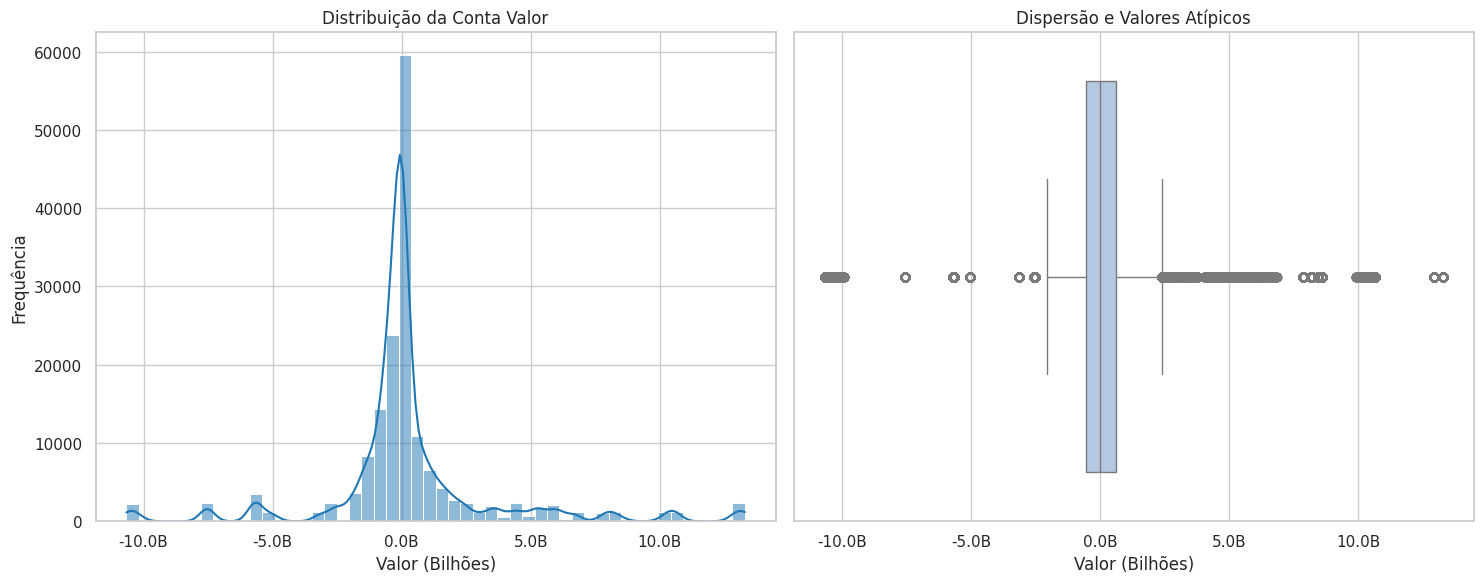

In [7]:
# Formatar os números em Bilhões
def formatar_bilhoes(x, pos):
    return f'{x*1e-9:.1f}B'

# Dois gráficos
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Histograma
sns.histplot(df['Valor'], bins=50, kde=True, ax=ax[0], color='#1f77b4')
ax[0].set_title('Distribuição da Conta Valor')
ax[0].set_xlabel('Valor (Bilhões)')
ax[0].set_ylabel('Frequência')
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(formatar_bilhoes))

# Boxplot
sns.boxplot(x=df['Valor'], ax=ax[1], color='#aec7e8')
ax[1].set_title('Dispersão e Valores Atípicos')
ax[1].set_xlabel('Valor (Bilhões)')
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(formatar_bilhoes))

# Ajustar o layout
plt.tight_layout()
plt.show()